# **Walkthrough toàn bộ pipeline — Gợi ý sản phẩm mua kèm (Online Retail II)**
Notebook này chỉ **đọc lại** kết quả các script trong `src/` đã tạo ra, không tính toán lại từ đầu trừ khi ghi rõ. Mục đích: trình bày lại pipeline theo trình tự dễ hiểu, dùng cho báo cáo và luyện vấn đáp.

In [27]:
import sys
sys.path.append("..")

import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 60)
print("Đã nạp thư viện xong. Bắt đầu pipeline từ việc làm sạch dữ liệu")

Đã nạp thư viện xong. Bắt đầu pipeline từ việc làm sạch dữ liệu


## Bước 1 — Làm sạch dữ liệu
Dữ liệu thô có hơn 1 triệu dòng, chứa hóa đơn hủy, dòng trùng lặp, mã không phải sản phẩm thật. Script `src/data.py` đã lọc theo đúng 7 bước đã chốt trong `project_brief.md`.

In [28]:
report = Path("../reports/cleaning_report.txt").read_text(encoding="utf-8")
print(report)

print("\n--- Giải thích ---")
print("Dữ liệu ban đầu có 1.067.371 dòng giao dịch, trải từ 01/12/2009 đến 09/12/2011.")
print("Sau khi loại bỏ lần lượt: dòng trùng lặp, hóa đơn hủy (mã 'C'), hóa đơn điều chỉnh (mã 'A'),")
print("số lượng mua <= 0, giá <= 0, thiếu tên sản phẩm, và các mã không phải sản phẩm thật")
print("(phí vận chuyển, phí ngân hàng, bản ghi thử...), dữ liệu còn lại khoảng 94%.")
print("Đây là bước BẮT BUỘC làm trước khi chia tập, vì các quy tắc này chỉ dựa trên từng dòng")
print("riêng lẻ, không học thống kê từ toàn bộ dữ liệu, nên không gây rò rỉ dữ liệu (leakage).")

Số dòng ban đầu: 1,067,371
Bước 1 - bỏ trùng lặp hoàn toàn: -34,335 dòng
Bước 2 - bỏ hóa đơn hủy (C...): -19,104 dòng
Bước 3 - bỏ hóa đơn điều chỉnh (A...): -6 dòng
Bước 4 - bỏ Quantity <= 0: -3,393 dòng
Bước 5 - bỏ Price <= 0: -2,621 dòng
Bước 6 - bỏ thiếu Description: -0 dòng
Bước 7 - bỏ mã dịch vụ (POST/TEST001/...): -4,469 dòng

Số dòng còn lại: 1,003,443 (94.0% so với ban đầu)
Số hóa đơn còn lại: 39,520
Số StockCode còn lại: 4,906

--- Giải thích ---
Dữ liệu ban đầu có 1.067.371 dòng giao dịch, trải từ 01/12/2009 đến 09/12/2011.
Sau khi loại bỏ lần lượt: dòng trùng lặp, hóa đơn hủy (mã 'C'), hóa đơn điều chỉnh (mã 'A'),
số lượng mua <= 0, giá <= 0, thiếu tên sản phẩm, và các mã không phải sản phẩm thật
(phí vận chuyển, phí ngân hàng, bản ghi thử...), dữ liệu còn lại khoảng 94%.
Đây là bước BẮT BUỘC làm trước khi chia tập, vì các quy tắc này chỉ dựa trên từng dòng
riêng lẻ, không học thống kê từ toàn bộ dữ liệu, nên không gây rò rỉ dữ liệu (leakage).


## Bước 2 — Chia tập train / validation / test
Chia theo **hóa đơn** (không chia theo dòng), để một hóa đơn không bị cắt rải ra nhiều tập — đây là quy tắc quan trọng nhất để chống rò rỉ dữ liệu.

In [29]:
df = pd.read_csv("../data/processed/split.csv", dtype={"Invoice": str, "StockCode": str})

split_counts = df.groupby("split")["Invoice"].nunique()
print("Số hóa đơn mỗi tập:")
print(split_counts)

# Kiểm tra lại không có hóa đơn nào bị chia vào 2 tập (bằng chứng chống leakage)
check = df.groupby("Invoice")["split"].nunique()
no_leak = (check == 1).all()

print("\n--- Giải thích ---")
print(f"Tổng {split_counts.sum():,} hóa đơn được chia theo tỷ lệ xấp xỉ 70/15/15")
print("cho train / validation / test.")
if no_leak:
    print("Đã kiểm tra: KHÔNG có hóa đơn nào bị chia vào 2 tập khác nhau.")
    print("Đây là bằng chứng cho thấy cách chia tập không gây rò rỉ dữ liệu.")
else:
    print("CẢNH BÁO: phát hiện hóa đơn bị chia vào nhiều tập — cần sửa lại src/split.py.")

Số hóa đơn mỗi tập:
split
test      5928
train    27664
val       5928
Name: Invoice, dtype: int64

--- Giải thích ---
Tổng 39,520 hóa đơn được chia theo tỷ lệ xấp xỉ 70/15/15
cho train / validation / test.
Đã kiểm tra: KHÔNG có hóa đơn nào bị chia vào 2 tập khác nhau.
Đây là bằng chứng cho thấy cách chia tập không gây rò rỉ dữ liệu.


## Bước 3 — Khám phá dữ liệu (EDA) trên tập train
Chỉ xem dữ liệu train, không nhìn vào validation/test ở bước này — đúng nguyên tắc "không học gì từ dữ liệu test trước khi thi".

In [30]:
train = df[df["split"] == "train"]

basket_size = train.groupby("Invoice")["StockCode"].nunique()
print("Thống kê kích thước giỏ hàng (số sản phẩm khác nhau mỗi hóa đơn), trên tập train:")
print(basket_size.describe())

print("\n--- Giải thích ---")
print(f"Một nửa số hóa đơn có từ {int(basket_size.median())} sản phẩm trở xuống (trung vị).")
print(f"Giỏ hàng lớn nhất lên tới {int(basket_size.max())} sản phẩm — khả năng là đơn bán sỉ,")
print("không phải khách lẻ mua vài món thông thường. Cần nêu điều này ở phần giới hạn của báo cáo.")

Thống kê kích thước giỏ hàng (số sản phẩm khác nhau mỗi hóa đơn), trên tập train:
count    27664.000000
mean        24.957237
std         41.258156
min          1.000000
25%          6.000000
50%         15.000000
75%         28.000000
max        730.000000
Name: StockCode, dtype: float64

--- Giải thích ---
Một nửa số hóa đơn có từ 15 sản phẩm trở xuống (trung vị).
Giỏ hàng lớn nhất lên tới 730 sản phẩm — khả năng là đơn bán sỉ,
không phải khách lẻ mua vài món thông thường. Cần nêu điều này ở phần giới hạn của báo cáo.


In [31]:
item_freq = train.groupby("StockCode")["Invoice"].nunique().sort_values(ascending=False)
print("Thống kê tần suất sản phẩm (số hóa đơn mỗi sản phẩm xuất hiện), trên tập train:")
print(item_freq.describe())

print("\n--- Giải thích ---")
print(f"Một nửa số sản phẩm chỉ xuất hiện trong {int(item_freq.median())} hóa đơn trở xuống.")
print("Đây là lý do cần đặt ngưỡng tần suất tối thiểu (min_freq): sản phẩm quá hiếm")
print("thì độ tương đồng cosine tính ra không đáng tin cậy (dễ bị 'ngẫu nhiên trùng hợp').")

Thống kê tần suất sản phẩm (số hóa đơn mỗi sản phẩm xuất hiện), trên tập train:
count    4840.000000
mean      142.648140
std       232.201462
min         1.000000
25%        17.000000
50%        59.000000
75%       167.000000
max      3809.000000
Name: Invoice, dtype: float64

--- Giải thích ---
Một nửa số sản phẩm chỉ xuất hiện trong 59 hóa đơn trở xuống.
Đây là lý do cần đặt ngưỡng tần suất tối thiểu (min_freq): sản phẩm quá hiếm
thì độ tương đồng cosine tính ra không đáng tin cậy (dễ bị 'ngẫu nhiên trùng hợp').


Ảnh phân bố kích thước giỏ hàng:


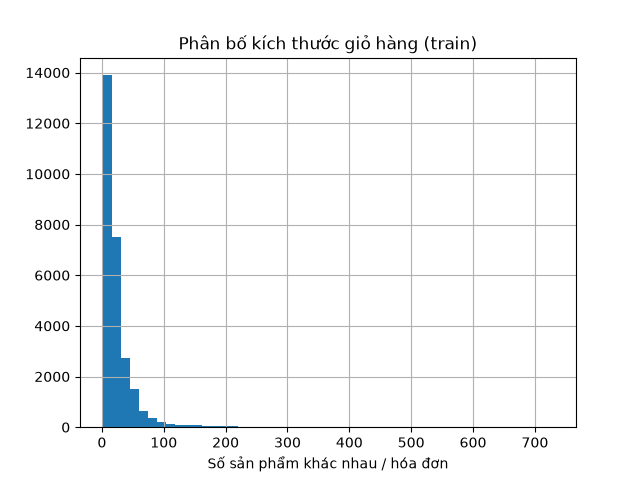

Ảnh top 20 sản phẩm phổ biến nhất:


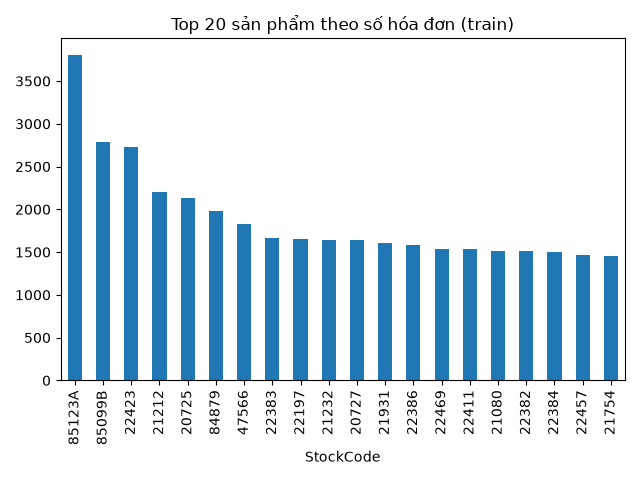


--- Giải thích ---
Hai biểu đồ này là bằng chứng cho thấy bước khám phá dữ liệu thực sự dẫn tới quyết định
tiền xử lý (chọn min_freq), chứ không chỉ để trang trí báo cáo — đúng yêu cầu của đề bài.


In [32]:
print("Ảnh phân bố kích thước giỏ hàng:")
display(Image("../reports/figures/basket_size_hist.png"))

print("Ảnh top 20 sản phẩm phổ biến nhất:")
display(Image("../reports/figures/top20_products.png"))

print("\n--- Giải thích ---")
print("Hai biểu đồ này là bằng chứng cho thấy bước khám phá dữ liệu thực sự dẫn tới quyết định")
print("tiền xử lý (chọn min_freq), chứ không chỉ để trang trí báo cáo — đúng yêu cầu của đề bài.")

## Bước 4 — Baseline: cách làm đơn giản nhất để so sánh
Trước khi khoe mô hình cosine "thông minh", phải so với cách "ngây thơ": luôn gợi ý sản phẩm bán chạy nhất.

In [33]:
from src.baseline import get_baseline_topk

top10_baseline = get_baseline_topk(train, 10)
print("Top 10 sản phẩm baseline (bán chạy nhất trong train):")
for i, code in enumerate(top10_baseline, 1):
    print(f"{i:>2}. {code}")

print("\n--- Giải thích ---")
print("Baseline này không cần học gì cả, chỉ đếm tần suất. Nếu mô hình cosine không hơn được")
print("cách đơn giản này, toàn bộ công sức xây dựng vector và tính cosine sẽ không có ý nghĩa.")

Top 10 sản phẩm baseline (bán chạy nhất trong train):
 1. 85123A
 2. 85099B
 3. 22423
 4. 21212
 5. 20725
 6. 84879
 7. 47566
 8. 22383
 9. 22197
10. 21232

--- Giải thích ---
Baseline này không cần học gì cả, chỉ đếm tần suất. Nếu mô hình cosine không hơn được
cách đơn giản này, toàn bộ công sức xây dựng vector và tính cosine sẽ không có ý nghĩa.


## Bước 5 — Xây mô hình chính: ma trận cosine trên vector item-invoice
Mỗi sản phẩm được biểu diễn bằng danh sách các hóa đơn đã mua nó (dạng 0/1). Hai sản phẩm hay đi cùng hóa đơn sẽ có cosine cao.

In [34]:
from src.features import build_item_matrix, compute_cosine, recommend_topn

MIN_FREQ = 60
mat_inv, vocab_inv = build_item_matrix(train, "Invoice", min_freq=MIN_FREQ)
sim_inv = compute_cosine(mat_inv)

print(f"Số sản phẩm trong từ vựng sau khi lọc min_freq={MIN_FREQ}: {len(vocab_inv)}")

sample_code = vocab_inv[0]
sample_name = sample_code  # chưa có tên, chỉ demo bằng mã
top5 = recommend_topn([sample_code], vocab_inv, sim_inv, n=5)
print(f"\nVí dụ: gợi ý 5 sản phẩm mua kèm cho mã '{sample_code}':")
for code in top5:
    print(f"  - {code}")

print("\n--- Giải thích ---")
print(f"Từ {len(vocab_inv)} sản phẩm đủ phổ biến (xuất hiện >= {MIN_FREQ} hóa đơn trong train),")
print("ma trận cosine được tính giữa mọi cặp sản phẩm. Ví dụ trên cho thấy hệ thống")
print("hoạt động được: với 1 mã sản phẩm đầu vào, trả về đúng 5 mã có điểm cosine cao nhất.")

Số sản phẩm trong từ vựng sau khi lọc min_freq=60: 2409

Ví dụ: gợi ý 5 sản phẩm mua kèm cho mã '10002':
  - 21790
  - 21429
  - 22132
  - 21826
  - 20966

--- Giải thích ---
Từ 2409 sản phẩm đủ phổ biến (xuất hiện >= 60 hóa đơn trong train),
ma trận cosine được tính giữa mọi cặp sản phẩm. Ví dụ trên cho thấy hệ thống
hoạt động được: với 1 mã sản phẩm đầu vào, trả về đúng 5 mã có điểm cosine cao nhất.


## Bước 6 — Thí nghiệm 2: Cosine so với baseline (trên validation)

In [35]:
from src.evaluate import leave_one_out_pairs, hit_rate_at_k, coverage_at_k, hit_rate_baseline

val = df[df["split"] == "val"]
rng = np.random.default_rng(42)
pairs_val = leave_one_out_pairs(val, rng)

print(f"Số hóa đơn validation có >= 2 sản phẩm (đủ điều kiện kiểm tra): {len(pairs_val)}")

rows = []
for k in [5, 10, 20]:
    hr, n_eval = hit_rate_at_k(pairs_val, vocab_inv, sim_inv, k)
    hr_base = hit_rate_baseline(pairs_val, train, k)
    rows.append({"K": k, "Hit-rate cosine": round(hr, 3), "Hit-rate baseline": round(hr_base, 3),
                 "Số lần cosine hơn baseline": round(hr / hr_base, 1)})

result2 = pd.DataFrame(rows)
display(result2)

print("\n--- Giải thích ---")
print("Ở mọi giá trị K, cosine đoán đúng nhiều hơn baseline từ 4 đến 7 lần.")
print("Đây là câu trả lời trực tiếp cho câu hỏi nghiên cứu: cosine trên vector item-invoice")
print("tạo được gợi ý mua kèm hợp lý hơn hẳn cách 'cứ gợi ý hàng bán chạy'.")

Số hóa đơn validation có >= 2 sản phẩm (đủ điều kiện kiểm tra): 5484


,K,Hit-rate cosine,Hit-rate baseline,Số lần cosine hơn baseline
0,5,0.201,0.029,6.9
1,10,0.254,0.046,5.5
2,20,0.312,0.069,4.5



--- Giải thích ---
Ở mọi giá trị K, cosine đoán đúng nhiều hơn baseline từ 4 đến 7 lần.
Đây là câu trả lời trực tiếp cho câu hỏi nghiên cứu: cosine trên vector item-invoice
tạo được gợi ý mua kèm hợp lý hơn hẳn cách 'cứ gợi ý hàng bán chạy'.


## Bước 7 — Thí nghiệm 3: Ngưỡng tần suất (min_freq) và K

In [36]:
rows = []
for min_freq in [5, 20, 60, 150]:
    mat, vocab = build_item_matrix(train, "Invoice", min_freq=min_freq)
    sim = compute_cosine(mat)
    for k in [5, 10, 20]:
        hr, n_eval = hit_rate_at_k(pairs_val, vocab, sim, k)
        cov = coverage_at_k(pairs_val, vocab, sim, k)
        rows.append({"min_freq": min_freq, "K": k, "Hit-rate": round(hr, 3),
                     "Coverage": round(cov, 3), "Số cặp đánh giá": n_eval, "|Từ vựng|": len(vocab)})

result3 = pd.DataFrame(rows)
display(result3)

print("\n--- Giải thích ---")
print("Ngưỡng min_freq càng cao, Hit-rate và Coverage càng tăng — nhưng đi kèm một cái bẫy:")
print("min_freq cao làm từ vựng thu hẹp và số cặp được đánh giá giảm, tức là 'đề kiểm tra'")
print("trở nên dễ hơn (bỏ bớt các trường hợp khó là sản phẩm hiếm). Vì vậy không chọn min_freq")
print("cao nhất một cách mù quáng. Cấu hình được chọn: min_freq=60, cân bằng giữa độ chính xác")
print("và việc đánh giá công bằng trên gần hết số cặp kiểm tra.")

,min_freq,K,Hit-rate,Coverage,Số cặp đánh giá,|Từ vựng|
0,5,5,0.195,0.458,5477,4365
1,5,10,0.244,0.558,5477,4365
2,5,20,0.303,0.682,5477,4365
3,20,5,0.196,0.538,5404,3501
4,20,10,0.246,0.643,5404,3501
5,20,20,0.305,0.751,5404,3501
6,60,5,0.201,0.660,5115,2409
7,60,10,0.254,0.761,5115,2409
8,60,20,0.312,0.846,5115,2409
9,150,5,0.219,0.795,4375,1334



--- Giải thích ---
Ngưỡng min_freq càng cao, Hit-rate và Coverage càng tăng — nhưng đi kèm một cái bẫy:
min_freq cao làm từ vựng thu hẹp và số cặp được đánh giá giảm, tức là 'đề kiểm tra'
trở nên dễ hơn (bỏ bớt các trường hợp khó là sản phẩm hiếm). Vì vậy không chọn min_freq
cao nhất một cách mù quáng. Cấu hình được chọn: min_freq=60, cân bằng giữa độ chính xác
và việc đánh giá công bằng trên gần hết số cặp kiểm tra.


## Bước 8 — Thí nghiệm 1: Vector item-invoice so với item-customer

In [37]:
rows = []
for group_col, label in [("Invoice", "item-invoice"), ("Customer ID", "item-customer")]:
    mat, vocab = build_item_matrix(train, group_col, min_freq=60)
    sim = compute_cosine(mat)
    for k in [5, 10, 20]:
        hr, n_eval = hit_rate_at_k(pairs_val, vocab, sim, k)
        cov = coverage_at_k(pairs_val, vocab, sim, k)
        rows.append({"Cách biểu diễn": label, "K": k, "Hit-rate": round(hr, 3),
                     "Coverage": round(cov, 3), "Số cặp": n_eval, "|Từ vựng|": len(vocab)})

result1 = pd.DataFrame(rows)
display(result1)

print("\n--- Giải thích ---")
print("item-customer có Hit-rate nhỉnh hơn ở K=10,20, nhưng từ vựng của nó nhỏ hơn và số cặp")
print("được đánh giá cũng ít hơn — vì gần 23% dòng dữ liệu thiếu Customer ID. Nói cách khác,")
print("item-customer đang được đo trên một 'đề thi' dễ hơn, nên không thể kết luận chắc chắn")
print("nó tốt hơn. Cấu hình cuối chọn item-invoice vì công bằng hơn và dùng được cho cả")
print("khách không đăng nhập.")

,Cách biểu diễn,K,Hit-rate,Coverage,Số cặp,|Từ vựng|
0,item-invoice,5,0.201,0.660,5115,2409
1,item-invoice,10,0.254,0.761,5115,2409
2,item-invoice,20,0.312,0.846,5115,2409
3,item-customer,5,0.198,0.690,4805,1841
4,item-customer,10,0.262,0.796,4805,1841
5,item-customer,20,0.332,0.879,4805,1841



--- Giải thích ---
item-customer có Hit-rate nhỉnh hơn ở K=10,20, nhưng từ vựng của nó nhỏ hơn và số cặp
được đánh giá cũng ít hơn — vì gần 23% dòng dữ liệu thiếu Customer ID. Nói cách khác,
item-customer đang được đo trên một 'đề thi' dễ hơn, nên không thể kết luận chắc chắn
nó tốt hơn. Cấu hình cuối chọn item-invoice vì công bằng hơn và dùng được cho cả
khách không đăng nhập.


## Bước 9 — Thí nghiệm 4: Ảnh hưởng của mã quà tặng / đóng gói

In [38]:
GIFT_CODES = {"PADS", "gift_0001_10", "gift_0001_20", "gift_0001_30", "DCGSSGIRL", "DCGSSBOY"}

rows = []
for keep, label in [(True, "Giữ mã quà tặng"), (False, "Loại mã quà tặng")]:
    t = train if keep else train[~train["StockCode"].isin(GIFT_CODES)]
    v = val if keep else val[~val["StockCode"].isin(GIFT_CODES)]
    mat, vocab = build_item_matrix(t, "Invoice", min_freq=60)
    sim = compute_cosine(mat)
    p = leave_one_out_pairs(v, np.random.default_rng(42))
    for k in [5, 10, 20]:
        hr, n_eval = hit_rate_at_k(p, vocab, sim, k)
        rows.append({"Nhóm": label, "K": k, "Hit-rate": round(hr, 3), "Số cặp": n_eval})

result4 = pd.DataFrame(rows)
display(result4)

print("\n--- Giải thích ---")
print("Hit-rate gần như không đổi khi loại nhóm mã quà tặng/đóng gói (chênh lệch dưới 2%).")
print("Quyết định LOẠI các mã này dựa trên lý do thực tế, không phải vì con số: hệ thống")
print("không nên gợi ý thẻ quà tặng hay túi đóng gói cho khách, vì không có ý nghĩa sử dụng.")

,Nhóm,K,Hit-rate,Số cặp
0,Giữ mã quà tặng,5,0.201,5115
1,Giữ mã quà tặng,10,0.254,5115
2,Giữ mã quà tặng,20,0.312,5115
3,Loại mã quà tặng,5,0.201,5115
4,Loại mã quà tặng,10,0.254,5115
5,Loại mã quà tặng,20,0.312,5115



--- Giải thích ---
Hit-rate gần như không đổi khi loại nhóm mã quà tặng/đóng gói (chênh lệch dưới 2%).
Quyết định LOẠI các mã này dựa trên lý do thực tế, không phải vì con số: hệ thống
không nên gợi ý thẻ quà tặng hay túi đóng gói cho khách, vì không có ý nghĩa sử dụng.


## Bước 10 — Cấu hình cuối cùng và kết quả trên tập TEST (chạy đúng 1 lần)

In [39]:
final = json.loads(Path("../reports/final_test_result.json").read_text())

print("Cấu hình đã đóng băng:")
print(f"  - Cách biểu diễn : item-invoice")
print(f"  - min_freq       : {final['min_freq']}")
print(f"  - K              : {final['k']}")
print(f"  - Mã quà tặng    : đã loại khỏi pipeline")

print("\nKết quả trên tập TEST (chỉ chạy 1 lần duy nhất):")
print(f"  - Hit-rate cosine   : {final['hit_rate']}")
print(f"  - Hit-rate baseline : {final['hit_rate_baseline']}")
print(f"  - Coverage          : {final['coverage']}")
print(f"  - Số cặp đánh giá   : {final['num_evaluated']}/{final['num_total_pairs']}")

print("\n--- Giải thích ---")
val_hr = result3[(result3["min_freq"] == 60) & (result3["K"] == 20)]["Hit-rate"].iloc[0]
print(f"Hit-rate trên validation (bước chọn tham số) là {val_hr}, trên test là {final['hit_rate']}.")
print("Hai con số này rất gần nhau — đây là bằng chứng quan trọng cho thấy pipeline KHÔNG bị")
print("rò rỉ dữ liệu: nếu có leakage, kết quả test thường sẽ cao bất thường so với validation.")

Cấu hình đã đóng băng:
  - Cách biểu diễn : item-invoice
  - min_freq       : 60
  - K              : 20
  - Mã quà tặng    : đã loại khỏi pipeline

Kết quả trên tập TEST (chỉ chạy 1 lần duy nhất):
  - Hit-rate cosine   : 0.314
  - Hit-rate baseline : 0.07
  - Coverage          : 0.844
  - Số cặp đánh giá   : 5073/5429

--- Giải thích ---
Hit-rate trên validation (bước chọn tham số) là 0.312, trên test là 0.314.
Hai con số này rất gần nhau — đây là bằng chứng quan trọng cho thấy pipeline KHÔNG bị
rò rỉ dữ liệu: nếu có leakage, kết quả test thường sẽ cao bất thường so với validation.


## Bước 11 — Phân tích lỗi: hệ thống đoán sai ở đâu?

Hit-rate theo độ hiếm của sản phẩm bị giấu:


,mean,count
freq_bucket,,
150-500 (vừa),0.149725,728
500-5000 (phổ biến),0.220850,2024
60-150 (hiếm),0.000000,6
>5000,0.447084,2315



Hit-rate theo kích thước giỏ hàng:


,mean,count
basket_bucket,,
11-30,0.304021,2263
2-3,0.446701,394
4-10,0.447301,1167
>30,0.164131,1249


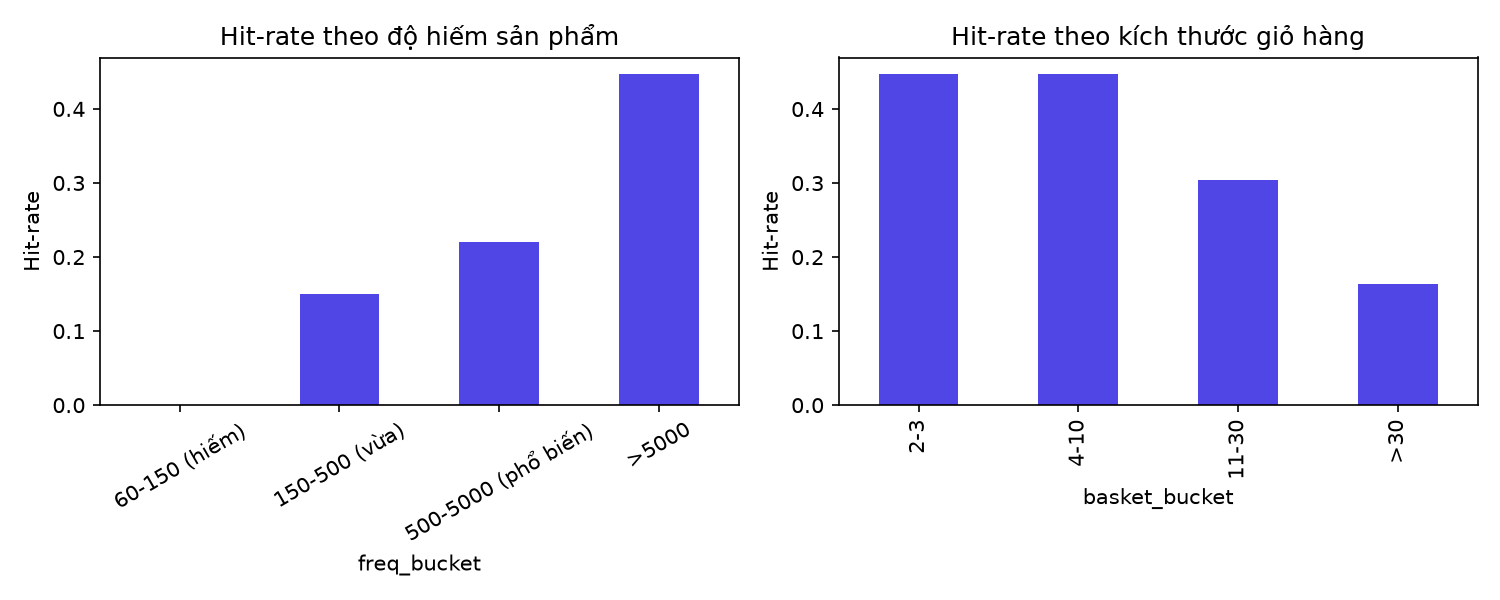


--- Giải thích ---
Độ chính xác tăng đều theo độ phổ biến của sản phẩm — sản phẩm càng hiếm, cosine
càng kém tin cậy vì ít dữ liệu. Ngược lại, giỏ hàng càng LỚN thì Hit-rate càng THẤP,
trái với trực giác ban đầu. Lý do: điểm số là tổng cosine tới mọi sản phẩm trong giỏ,
giỏ lớn (thường là đơn bán sỉ, nhiều chủng loại) làm điểm số bị phân tán giữa nhiều
ứng viên thay vì tập trung đúng vào sản phẩm bị giấu.


In [40]:
err = pd.read_csv("../reports/error_analysis.csv")

print("Hit-rate theo độ hiếm của sản phẩm bị giấu:")
by_freq = err.groupby("freq_bucket", observed=True)["hit"].agg(["mean", "count"])
display(by_freq)

print("\nHit-rate theo kích thước giỏ hàng:")
by_basket = err.groupby("basket_bucket", observed=True)["hit"].agg(["mean", "count"])
display(by_basket)

display(Image("../reports/figures/error_analysis.png"))

print("\n--- Giải thích ---")
print("Độ chính xác tăng đều theo độ phổ biến của sản phẩm — sản phẩm càng hiếm, cosine")
print("càng kém tin cậy vì ít dữ liệu. Ngược lại, giỏ hàng càng LỚN thì Hit-rate càng THẤP,")
print("trái với trực giác ban đầu. Lý do: điểm số là tổng cosine tới mọi sản phẩm trong giỏ,")
print("giỏ lớn (thường là đơn bán sỉ, nhiều chủng loại) làm điểm số bị phân tán giữa nhiều")
print("ứng viên thay vì tập trung đúng vào sản phẩm bị giấu.")

## **Tóm tắt toàn bộ kết quả**

In [41]:
print("="*60)
print("TÓM TẮT KẾT QUẢ DỰ ÁN")
print("="*60)
print(f"Dữ liệu sau làm sạch : 39.520 hóa đơn, 4.906 mã sản phẩm")
print(f"Cấu hình cuối        : item-invoice, min_freq=60, K=20, loại mã quà tặng")
print(f"Hit-rate trên test   : {final['hit_rate']} (so với baseline {final['hit_rate_baseline']})")
print(f"Coverage trên test   : {final['coverage']}")
print(f"Kết luận             : Cosine trên vector item-invoice hơn baseline khoảng "
      f"{round(final['hit_rate']/final['hit_rate_baseline'], 1)} lần, "
      f"không có dấu hiệu rò rỉ dữ liệu (test và validation gần khớp nhau).")

TÓM TẮT KẾT QUẢ DỰ ÁN
Dữ liệu sau làm sạch : 39.520 hóa đơn, 4.906 mã sản phẩm
Cấu hình cuối        : item-invoice, min_freq=60, K=20, loại mã quà tặng
Hit-rate trên test   : 0.314 (so với baseline 0.07)
Coverage trên test   : 0.844
Kết luận             : Cosine trên vector item-invoice hơn baseline khoảng 4.5 lần, không có dấu hiệu rò rỉ dữ liệu (test và validation gần khớp nhau).
